In [1]:
#!pip install transformers datasets torch scikit-learn pandas

**Setup: Install & Import Library**

In [1]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from pathlib import Path

from transformers import EarlyStoppingCallback

**Tahap 1: Membaca Dataset**

In [6]:
possible_paths = [
    Path('../dataset/dataset_clean_final.csv'),
    Path('dataset_clean_final.csv'),
    Path('/content/dataset_clean_final.csv')
]

for path in possible_paths:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Dataset berhasil dibaca dari: {path}")
        break
else:
    raise FileNotFoundError('File dataset_clean_final.csv tidak ditemukan. Pastikan file berada di folder dataset atau satu folder dengan notebook.')

Dataset berhasil dibaca dari: ..\dataset\dataset_clean_final.csv


In [7]:
# Load dataset
df = df.dropna(subset=['text', 'label'])
df.head()

,text,label
0,makin yakin habis baca review lain tentang vic...,1
1,paling suka model h2 smiling_face_with_heart e...,0
2,mobilnya sudah hancur pleading_face,0
3,manut88benar2 bikin aku jadi sultan,1
4,semoga lekas recover mobilnya mas dipo,0


**Tahap 2: Pembagian Dataset (80/20 Stratified)**

In [8]:
# Membagi dataset menjadi 80% Training dan 20% Validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label'] # Menjaga rasio label tetap seimbang
)

# Konversi format list biasa menjadi format 'Dataset' bawaan Hugging Face
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
val_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels})

print(f"Jumlah data latih: {len(train_dataset)}")
print(f"Jumlah data validasi: {len(val_dataset)}")

Jumlah data latih: 56303
Jumlah data validasi: 14076


**Tahap 3: Tokenisasi dengan IndoBERT**

In [9]:
# Menggunakan pre-trained model IndoBERT
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # max_length=128 cukup ideal untuk komentar YouTube
    # padding & truncation memastikan semua input memiliki panjang seragam
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Menerapkan tokenisasi ke seluruh data latih dan validasi secara massal (batched)
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print("Proses tokenisasi selesai!")

Map:   0%|          | 0/56303 [00:00<?, ? examples/s]

Map:   0%|          | 0/14076 [00:00<?, ? examples/s]

Proses tokenisasi selesai!


**Tahap 4: Definisi Metrik Evaluasi**

In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Menghitung metrik klasifikasi biner
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**Tahap 5: Focal Loss & Custom Trainer (WeightedFocalTrainer)**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

# 1. Definisi Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Hitung Cross Entropy standar
        CE_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Probabilitas prediksi (pt)
        pt = torch.exp(-CE_loss)

        # Focal Modulator: (1 - pt)^gamma
        # Ini mengecilkan loss dari sampel yang MUDAH ditebak (kelas mayoritas)
        # dan membesarkan loss dari sampel yang SULIT (slang judol seperti 'wd', 'gacor')
        F_loss = ((1 - pt) ** self.gamma) * CE_loss

        # Aplikasikan Class Weight (alpha)
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            F_loss = at * F_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        return F_loss

# 2. Definisi Custom Trainer
class WeightedFocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Bobot Alpha: Kelas 0 = 1.0, Kelas 1 = 7.61 (Rasio 62227 / 8177)
        # Pindahkan tensor ke device yang sama dengan model (CPU/GPU)
        alpha = torch.tensor([1.0, 7.61], dtype=torch.float).to(logits.device)

        # Gamma = 2.0 adalah standar empiris untuk Focal Loss
        loss_fct = FocalLoss(alpha=alpha, gamma=2.0, reduction='mean')
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

**Tahap 6: Konfigurasi Model & Training Arguments**

In [ ]:
# Memuat model IndoBERT dengan spesifikasi 2 label kelas klasifikasi
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Konfigurasi argumen pelatihan yang dioptimalkan untuk RTX 3050 (6GB)
training_args = TrainingArguments(
    output_dir="./indobert_judol_model_focal",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused"
)

# Inisialisasi API Trainer
trainer = WeightedFocalTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Tahap 7: Proses Fine-Tuning IndoBERT**

In [10]:
# Memulai proses training
print("Memulai proses fine-tuning IndoBERT...")
trainer.train()

Memulai proses fine-tuning IndoBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.047896,0.028925,0.994317,0.975654,0.970927,0.980428
2,0.023871,0.031324,0.995808,0.981896,0.985222,0.978593
3,0.011075,0.040609,0.994885,0.978089,0.973349,0.982875
4,0.000743,0.052642,0.996022,0.982875,0.982875,0.982875
5,0.000379,0.053907,0.996377,0.984380,0.985890,0.982875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8800, training_loss=0.019459119474472986, metrics={'train_runtime': 3110.4206, 'train_samples_per_second': 90.507, 'train_steps_per_second': 2.829, 'total_flos': 1.85174271874176e+16, 'train_loss': 0.019459119474472986, 'epoch': 5.0})

**Tahap 8: Simpan Model & Tokenizer**

In [ ]:
# Menentukan nama folder penyimpanan
model_path = "../model/indobert_judol_model_focal"

# Menyimpan model dan tokenizer
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model berhasil disimpan di folder: {model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan di folder: ./model/indobert_judol_model_focal


**Tahap 9: Pengujian Inference dengan Pipeline**

In [13]:
from transformers import pipeline
model_path = "../model/indobert_judol_model_focal"

# Load model yang baru saja disimpan
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)

# Contoh teks pengujian
test_comments = [
    "Wah videonya sangat edukatif, terima kasih bang!",
    "Bongkar rahasia wd terus bosku, cek link di bio sekarang depo 10k jadi 100k",
    "Gacor banget bang mainnya, tutor dong"
]

# Jalankan prediksi
predictions = classifier(test_comments)

for text, pred in zip(test_comments, predictions):
    # Pipeline mengembalikan label sebenarnya (BUKAN_JUDOL / JUDOL) karena id2label ada di config
    label = pred['label']
    print(f"Komentar: {text}")
    print(f"Prediksi: {label} (Confidence: {pred['score']:.4f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Komentar: Wah videonya sangat edukatif, terima kasih bang!
Prediksi: BUKAN_JUDOL (Confidence: 0.9866)

Komentar: Bongkar rahasia wd terus bosku, cek link di bio sekarang depo 10k jadi 100k
Prediksi: JUDOL (Confidence: 0.9799)

Komentar: Gacor banget bang mainnya, tutor dong
Prediksi: BUKAN_JUDOL (Confidence: 0.9688)



**Tahap 10: Evaluasi Akhir — Classification Report & Confusion Matrix**

Menjalankan prediksi pada test set...



--- TEST DATA EVALUATION REPORT (IndoBERT + Focal Loss) ---
              precision    recall  f1-score   support

 Bukan Judol       0.91      0.50      0.65     12441
       Judol       0.14      0.62      0.23      1635

    accuracy                           0.52     14076
   macro avg       0.53      0.56      0.44     14076
weighted avg       0.82      0.52      0.60     14076



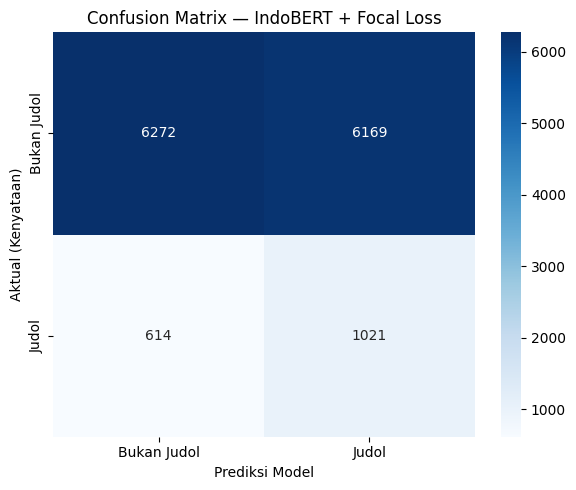

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Jalankan prediksi pada seluruh test set menggunakan Trainer
print("Menjalankan prediksi pada test set...")
predictions_output = trainer.predict(tokenized_val)

# Ambil prediksi dan label asli
preds_np = predictions_output.predictions.argmax(-1)
labels_np = predictions_output.label_ids

# Classification Report
print("\n--- TEST DATA EVALUATION REPORT (IndoBERT + Focal Loss) ---")
print(classification_report(labels_np, preds_np, target_names=['Bukan Judol', 'Judol']))

# Confusion Matrix
cm = confusion_matrix(labels_np, preds_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Judol', 'Judol'],
            yticklabels=['Bukan Judol', 'Judol'])
plt.ylabel('Aktual (Kenyataan)')
plt.xlabel('Prediksi Model')
plt.title('Confusion Matrix — IndoBERT + Focal Loss')
plt.tight_layout()
plt.show()

**Tahap 11: Error Analysis — False Positive & False Negative**

In [15]:
# Mengambil confidence score (probabilitas) untuk prediksi yang salah
probs = torch.softmax(torch.tensor(predictions_output.predictions), dim=-1)
confidence = probs.max(dim=-1).values.numpy()

# Membuat DataFrame error untuk analisis
error_df = pd.DataFrame({
    'text': val_texts,
    'label_asli': labels_np,
    'prediksi': preds_np,
    'confidence': confidence
})

# False Positive: model prediksi JUDOL, tapi aslinya BUKAN JUDOL (label 0, pred 1)
fp = error_df[(error_df['label_asli'] == 0) & (error_df['prediksi'] == 1)]
fp_sorted = fp.sort_values('confidence', ascending=False)

# False Negative: model prediksi BUKAN JUDOL, tapi aslinya JUDOL (label 1, pred 0)
fn = error_df[(error_df['label_asli'] == 1) & (error_df['prediksi'] == 0)]
fn_sorted = fn.sort_values('confidence', ascending=False)

print(f"Total False Positive (FP): {len(fp)} — komentar aman yang salah dikira judol")
print(f"Total False Negative (FN): {len(fn)} — komentar judol yang lolos deteksi")
print()

print("--- TOP 10 FALSE POSITIVE (Aman tapi dikira Judol) ---")
for i, row in fp_sorted.head(10).iterrows():
    print(f"  [{row['confidence']:.4f}] \"{row['text'][:100]}\"")

print()
print("--- TOP 10 FALSE NEGATIVE (Judol tapi lolos deteksi) ---")
for i, row in fn_sorted.head(10).iterrows():
    print(f"  [{row['confidence']:.4f}] \"{row['text'][:100]}\"")

Total False Positive (FP): 6169 — komentar aman yang salah dikira judol
Total False Negative (FN): 614 — komentar judol yang lolos deteksi

--- TOP 10 FALSE POSITIVE (Aman tapi dikira Judol) ---
  [0.6563] "saya mempunyai android nokia 6 nokia 5 3 dan sekarang memakai nokia 5 4 kualitas sungguh sangat luar"
  [0.6541] "review advan macha bang dari konten bang david"
  [0.6504] "korupsi lewat prosedur yaah muncul kan isu terorisme anggaran langsung cair ujung ujung nya di korup"
  [0.6471] "hahaha akhirnya sdh di fase ini dia parah men"
  [0.6462] "bang review smartwacht murah harga di bawah 100 yang bisa gps sama banyak olahraga"
  [0.6402] "min mau bertanya apakah plastik bisa dijadikan pengganti beton"
  [0.6384] "masyaallah mbk semoga allah selalu melindungi dan mempermudah urusannya iya"
  [0.6330] "sering bngt saya melihat towing nya garasi drift di rawa domba"
  [0.6285] "benar banyak bule kalau class sekarang bahkan banyak punya bisnis ilegal"
  [0.6270] "1 : 24 : 29 ekonomi men